In [1]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [2]:
env_name = "Pendulum-v1"
env = gym.make(env_name)

In [3]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 40 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [4]:
params = SB3_PARAMS
params["fit_steps"] = 1

In [5]:
random_seed = 0

In [6]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [7]:
hidden_sizes = [256, 256]
sac = from_dict(env=env, hidden_sizes=hidden_sizes, **params)

In [8]:
agent = sac
agent_name = "SAC"

In [9]:
filepath = f"./results2/{agent_name}-{env_name}-{random_seed}"

In [10]:
warmup_agent(agent, env, 256, max_timesteps)

In [11]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [12]:
losses, rewards, lengths, i_episode = train_agent(agent, env, i_episode, new_episodes, max_timesteps, filepath, losses, rewards, lengths, log_interval=1, save_interval=20, train_interval=1)

Episode 1 	 avg length: 200 	 reward: -1651.7333055103013
Episode 2 	 avg length: 200 	 reward: -1489.249546365077
Episode 3 	 avg length: 200 	 reward: -1456.820022408233
Episode 4 	 avg length: 200 	 reward: -1231.053877330368
Episode 5 	 avg length: 200 	 reward: -1373.2932941561369
Episode 6 	 avg length: 200 	 reward: -1398.7634352375871
Episode 7 	 avg length: 200 	 reward: -916.5122144245441
Episode 8 	 avg length: 200 	 reward: -1534.4418944462911
Episode 9 	 avg length: 200 	 reward: -1066.776988893153
Episode 10 	 avg length: 200 	 reward: -829.4877837523112
Episode 11 	 avg length: 200 	 reward: -797.7554970363386
Episode 12 	 avg length: 200 	 reward: -745.1317501431752
Episode 13 	 avg length: 200 	 reward: -509.79293947318274
Episode 14 	 avg length: 200 	 reward: -428.02742422308046
Episode 15 	 avg length: 200 	 reward: -385.7421343403617
Episode 16 	 avg length: 200 	 reward: -363.81724169879334
Episode 17 	 avg length: 200 	 reward: -235.07592264017447
Episode 18 	 av

In [ ]:
rewards, lengths, losses = load_stats(filepath) 

In [13]:
from sac.plots import *

In [14]:
plot_path = "plots2"

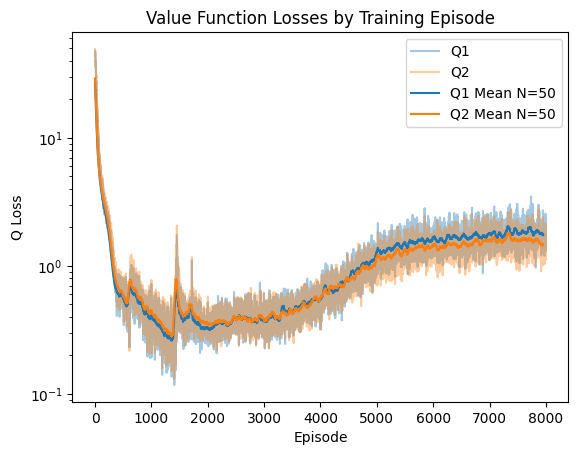

In [16]:
q_losses = np.asarray(losses)[:,0,:2]
plot_q(q_losses, plot_path)

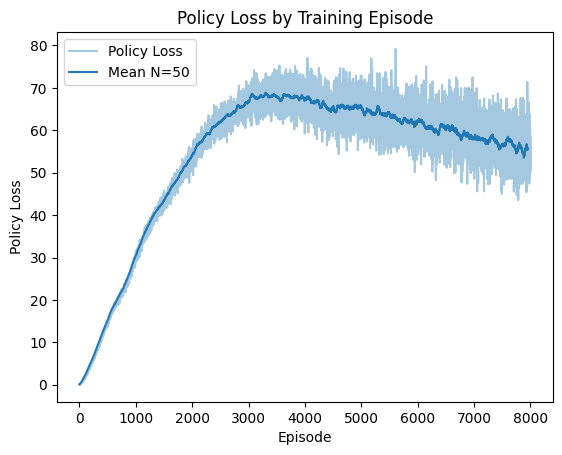

In [18]:
policy_loss = np.asarray(losses)[:,0,2]
plot_policy_loss(policy_loss, plot_path)

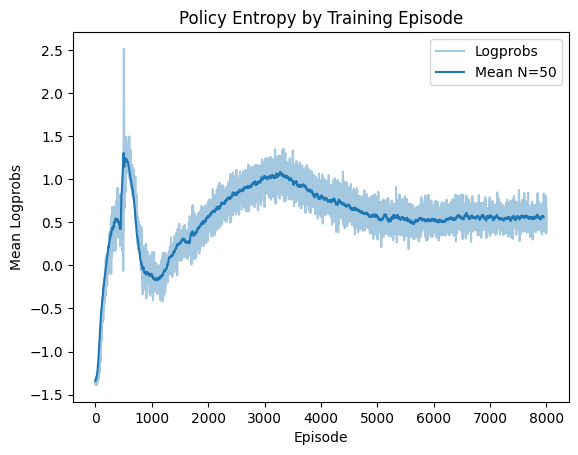

In [17]:
logprobs = np.asarray(losses)[:,0,-1]
plot_entropy(logprobs, plot_path)

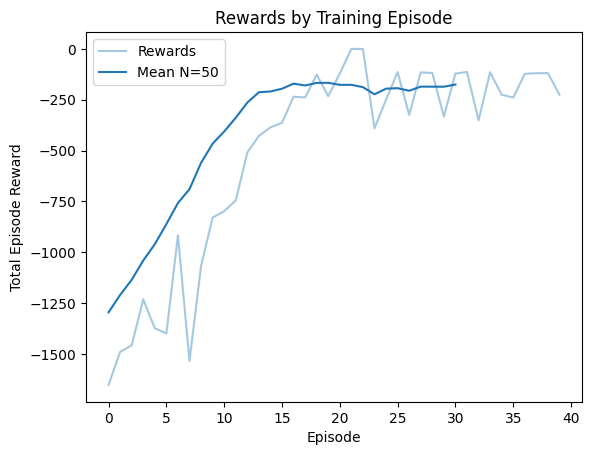

In [19]:
plot_rewards(rewards, plot_path, 10)